In [37]:
import numpy as np
import scipy as sp 
import glob
# from dyconnmap import tvfcg
# from dyconnmap.fc import IPLV, Corr
# from dyconnmap.cluster import NeuralGas
# from dyconnmap.ts import transition_rate, occupancy_time
# from dyconnmap.ts import markov_matrix
from tqdm import tqdm
from scipy.stats import zscore
from joblib import Parallel, delayed
import fathon
from fathon import fathonUtils as fu
from natsort import natsorted


In [38]:

%load_ext autoreload
%autoreload 2
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogLocator
plt.rcParams.update({'font.size': 8})
plt.rcParams.update({'pdf.fonttype':42})
plt.rcParams.update({'figure.max_open_warning': 0})

plt.rcParams['axes.spines.top'] = False


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
sjnr = '100307'

suffix = '_stabilitycheck_fftfix'
suffix = '_fftfix'

paths_e = natsorted(glob.glob(f'sim/{sjnr}_long{suffix}/beta_E_activity*.npz'))

dsample_1 = 40
nsim = 10
#dsample again if needed e.g. to 250hz for faster calculations
dsample_2 = 1
#dsample nodes
dsample_nodes = 40

sims = np.concatenate([np.load(p)['arr_0'][:,::dsample_2] for p in paths_e[:nsim]],axis=-1)

fs = 20000//(dsample_1*dsample_2)

eigenvectors = np.load(f'/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/eigenvectors.npy')

sims_g = np.dot(eigenvectors,sims)[::dsample_nodes]

del sims


In [56]:
paths_e = natsorted(glob.glob(f'sim/{sjnr}_long{suffix}/beta_I_activity*.npz'))

dsample_1 = 40
nsim = 10
#dsample again if needed e.g. to 250hz for faster calculations
dsample_2 = 1
#dsample nodes
dsample_nodes = 40

sims = np.concatenate([np.load(p)['arr_0'][:,::dsample_2] for p in paths_e[:nsim]],axis=-1)

fs = 20000//(dsample_1*dsample_2)

eigenvectors = np.load(f'/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/eigenvectors.npy')

sims_gi = np.dot(eigenvectors,sims)[::dsample_nodes]

del sims


In [57]:
if 'stabilitycheck' not in suffix:
    from scipy.stats import zscore
    #12,17,19,42,44,57,60,62,302,305,309,314,316,325,479,483,487,476,463,465

    #nodes = [12,17,19,42,44,57,60,62,302,305,309,314,316,325,479,483,487,476,463,465]
    # nodes=np.array(nodes)#+2
    #nodes = [7,19,12,27,20,21,44,112,142,132,168,161,174,200,199,193,195,228,221,226,495,501]
    nodes = np.arange(sims_g.shape[0])
    alpha_power = []
    for node in nodes:
        power_e = np.abs(np.fft.rfft(sims_g[node,:], axis=-1))**2
        power_e /= np.sum(power_e)
        power_i = np.abs(np.fft.rfft(sims_g[node,:], axis=-1))**2
        power_i /= np.sum(power_i)
        freqs = np.fft.rfftfreq(sims_g.shape[-1], d=1/500)
        #alpha_power.append(np.sum(power_e[(freqs>6) & (freqs<11)])+np.sum(power_i[(freqs>6) & (freqs<11)]))
        alpha_power.append(np.sum(power_e[(freqs>6) & (freqs<11)]))
        
    nodes=np.array(nodes)[np.argsort(alpha_power)[::-1]]



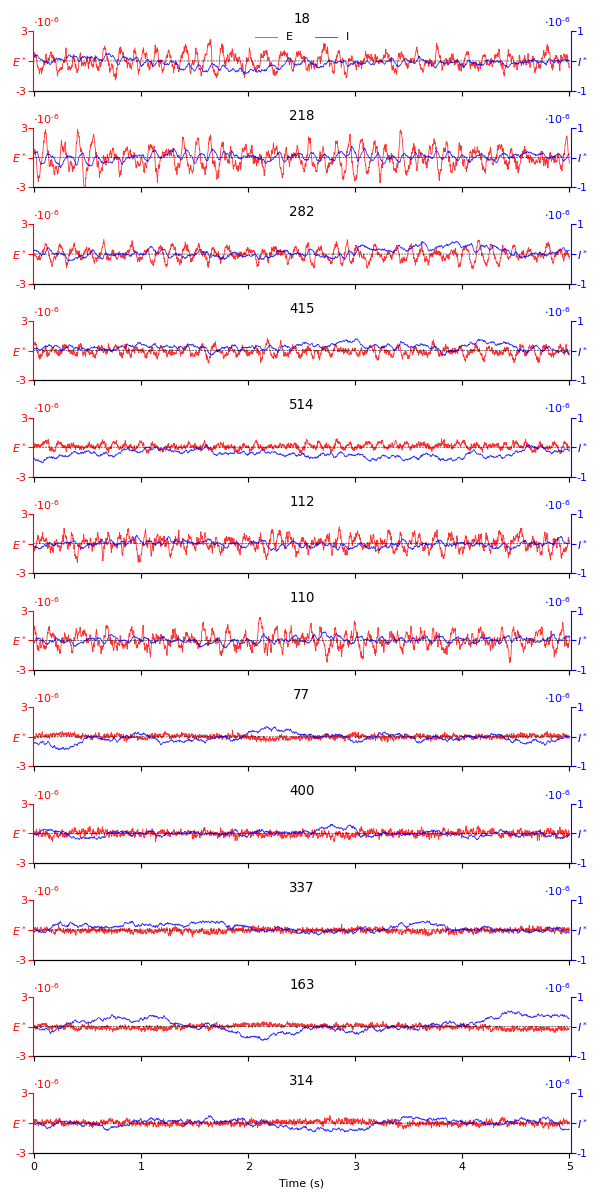

In [ ]:
from matplotlib.ticker import ScalarFormatter
import matplotlib as mpl

plt.close('all')

mpl.rcParams['axes.unicode_minus'] = False

class DotNotationFormatter(ScalarFormatter):
    """ScalarFormatter that uses ·10ⁿ with short minus, and replaces the 0 label with a custom string."""
    def __init__(self, zero_label=r'$E^*\!,I^*$', *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.set_useMathText(True)
        self.zero_label = zero_label

    def __call__(self, x, pos=None):
        if x == 0:
            return self.zero_label
        significand = x / (10 ** self.orderOfMagnitude)
        if significand == int(significand):
            return f'{int(significand)}'
        return f'{significand:g}'

    def get_offset(self):
        offset = super().get_offset()
        offset = offset.replace(r'\times', r'\cdot')
        offset = offset.replace(r'{-', r'{\text{-}')
        return offset

node_selection = [18,218,282,415,514,112,110,77,400,337,163,314] #[218,282,514,77]#
numodes = len(node_selection)

fig, ax = plt.subplots(numodes, figsize=(6, numodes), sharex=True, tight_layout=True)
for i, numnode in enumerate(node_selection):#nodes[-50:]):

    # Left axis: E (red)
    ax[i].plot(np.arange(-5, 2505), np.zeros(2510), c='k', ls='--', lw=0.4, zorder=2)
    ax[i].plot(sims_g[numnode, 1000:3500], c='r', lw=0.6, alpha=0.8, label='E', zorder=1)
    
    ax[i].set_xlim(-5, 2505)
    ax[i].set_title(numnode)

    # ylim_left = np.abs(ax[i].get_ylim()).max()
    # ax[i].set_ylim(-ylim_left, ylim_left)
    ylim_left = 3*10**(-6)
    ax[i].set_ylim(-ylim_left, ylim_left)

    formatter_left = DotNotationFormatter(zero_label=r'$E^*$')
    formatter_left.set_scientific(True)
    formatter_left.set_powerlimits((0, 0))
    

    ax[i].tick_params(axis='y', pad=1, colors='r')
    ax[i].spines['left'].set_color('r')
    ax[i].spines['right'].set_visible(False)
    ax[i].set_yticks([-ylim_left, 0, ylim_left],[-ylim_left, 0, ylim_left])
    ax[i].yaxis.set_major_formatter(formatter_left)

    if 'stabilitycheck' in suffix:
        ax[i].plot(500*np.ones(100), np.linspace(-ylim_left,ylim_left,100), ls='--', c='purple', label='P+ 0.05%', lw=1.5)
        

    # Right axis: I (blue)
    ax_right = ax[i].twinx()
    ax_right.plot(sims_gi[numnode, 1000:3500], c='b', lw=0.6, alpha=0.8, label='I',zorder=0)

    #ylim_right = np.abs(ax_right.get_ylim()).max()
    ax_right.set_ylim(-ylim_left/3, ylim_left/3)

    formatter_right = DotNotationFormatter(zero_label=r'$I^*$')
    formatter_right.set_scientific(True)
    formatter_right.set_powerlimits((0, 0))
    ax_right.yaxis.set_major_formatter(formatter_right)

    ax_right.tick_params(axis='y', pad=1, colors='b')
    ax_right.spines['right'].set_visible(True)
    ax_right.spines['right'].set_color('b')
    ax_right.spines['left'].set_visible(False)

    if i == 0:
        lines_left, labels_left = ax[i].get_legend_handles_labels()
        lines_right, labels_right = ax_right.get_legend_handles_labels()
        ax[i].legend(lines_left + lines_right, labels_left + labels_right,
                     loc='upper center', ncol=3, frameon=False,
                     bbox_to_anchor=(0.5, 1.15))

ax[-1].set_xticks([0, 500, 1000, 1500, 2000, 2500], [0, 1, 2, 3, 4, 5])
ax[-1].set_xlabel('Time (s)')
plt.savefig(f"new_example_timecourses_hcpmeg_wnoise{suffix}_selection.pdf", dpi=600, transparent=True)